# Section 1 — Install & Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings("ignore")

# Section 2 — Download Stock Data

In [2]:
stocks = {
    "Reliance": "RELIANCE.NS",
    "Infosys": "INFY.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "Tata Steel": "TATASTEEL.NS",
    "Sun Pharma": "SUNPHARMA.NS"
}

In [3]:
stock_data = {}

for name, ticker in stocks.items():

    print(f"Downloading {name} data...")

    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2025-12-31",
        interval="1d"
    )

    # Store dataframe
    stock_data[name] = data

    # Save CSV
    data.to_csv(f"{name.replace(' ', '_')}.csv")

print("All stock data downloaded successfully!")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

All stock data downloaded successfully!


In [4]:
for name, data in stock_data.items():
    print(f"\n{name}")
    print(data.head())


Reliance
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-01-01  901.194641  905.502206  898.700750  901.421320    10015175
2021-01-04  902.713684  906.363760  892.352763  904.640758    24513534
2021-01-05  891.491211  899.426244  886.911511  892.806130    24123091
2021-01-06  867.980774  891.445793  863.854552  891.400457    46401468
2021-01-07  866.575195  881.923840  863.854624  870.814757    32325918

Infosys
Price             Close         High          Low         Open    Volume
Ticker          INFY.NS      INFY.NS      INFY.NS      INFY.NS   INFY.NS
Date                                                                    
2021-01-01  1109.599609  1114.045270  1105.506206  1107.354857   4253550
2021-01-04  1134.072510  1135.613070  1110.215854  1117.126346   7208454
2021-01-05  1138.958496  1143.536119  1122.45249

# Section 3 — Data Cleaning

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1235 entries, 2021-01-01 to 2025-12-30
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, SUNPHARMA.NS)   1235 non-null   float64
 1   (High, SUNPHARMA.NS)    1235 non-null   float64
 2   (Low, SUNPHARMA.NS)     1235 non-null   float64
 3   (Open, SUNPHARMA.NS)    1235 non-null   float64
 4   (Volume, SUNPHARMA.NS)  1235 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 57.9 KB


### Already Clean

# Section 4 — Missing Value Handling

In [6]:
for name, data in stock_data.items():

    print(f"\n{name} Missing Values:")
    print(data.isnull().sum())


Reliance Missing Values:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Infosys Missing Values:
Price   Ticker 
Close   INFY.NS    0
High    INFY.NS    0
Low     INFY.NS    0
Open    INFY.NS    0
Volume  INFY.NS    0
dtype: int64

HDFC Bank Missing Values:
Price   Ticker     
Close   HDFCBANK.NS    0
High    HDFCBANK.NS    0
Low     HDFCBANK.NS    0
Open    HDFCBANK.NS    0
Volume  HDFCBANK.NS    0
dtype: int64

Tata Steel Missing Values:
Price   Ticker      
Close   TATASTEEL.NS    0
High    TATASTEEL.NS    0
Low     TATASTEEL.NS    0
Open    TATASTEEL.NS    0
Volume  TATASTEEL.NS    0
dtype: int64

Sun Pharma Missing Values:
Price   Ticker      
Close   SUNPHARMA.NS    0
High    SUNPHARMA.NS    0
Low     SUNPHARMA.NS    0
Open    SUNPHARMA.NS    0
Volume  SUNPHARMA.NS    0
dtype: int64


In [7]:
for name in stock_data:
    stock_data[name] = stock_data[name].ffill()

print("Missing values handled successfully!")

Missing values handled successfully!


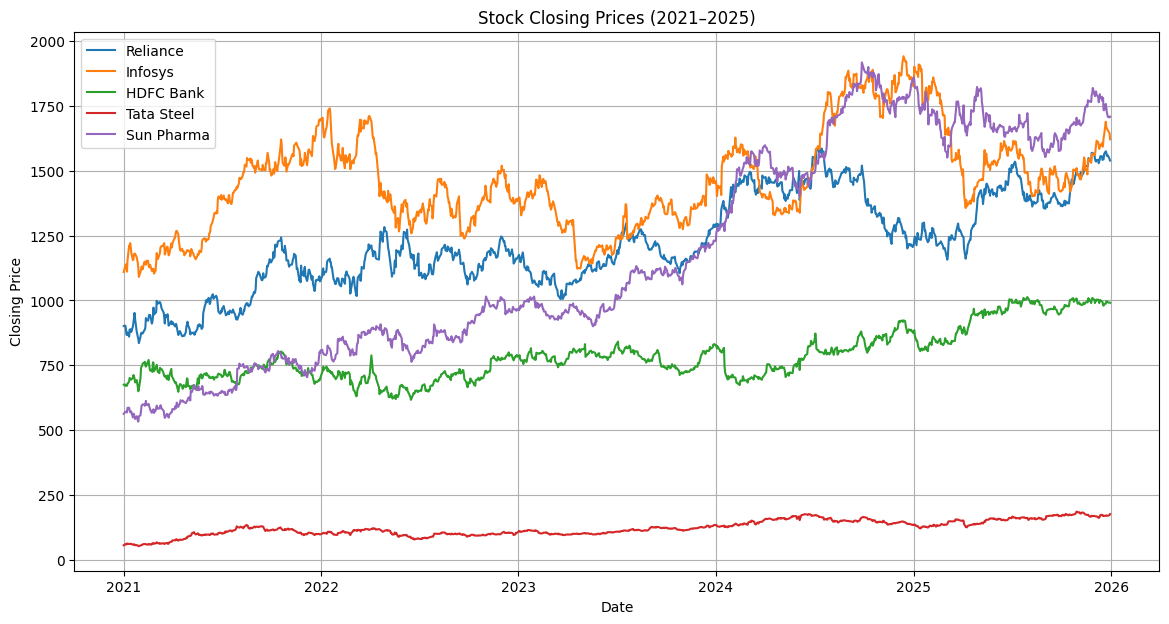

In [8]:
plt.figure(figsize=(14, 7))

for name, data in stock_data.items():

    plt.plot(data.index, data['Close'], label=name)

plt.title("Stock Closing Prices (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

# Section 5 — Train/Test Split

In [9]:
train_data = {}
test_data = {}

for name, data in stock_data.items():

    train = data[data.index < "2025-07-01"]
    test = data[data.index >= "2025-07-01"]

    train_data[name] = train
    test_data[name] = test

    print(f"\n{name}")
    print(f"Train Shape: {train.shape}")
    print(f"Test Shape: {test.shape}")


Reliance
Train Shape: (1110, 5)
Test Shape: (125, 5)

Infosys
Train Shape: (1110, 5)
Test Shape: (125, 5)

HDFC Bank
Train Shape: (1110, 5)
Test Shape: (125, 5)

Tata Steel
Train Shape: (1110, 5)
Test Shape: (125, 5)

Sun Pharma
Train Shape: (1110, 5)
Test Shape: (125, 5)


# Section 6 — Rolling Volatility

VERY important for:

* Task 4
* Task 5

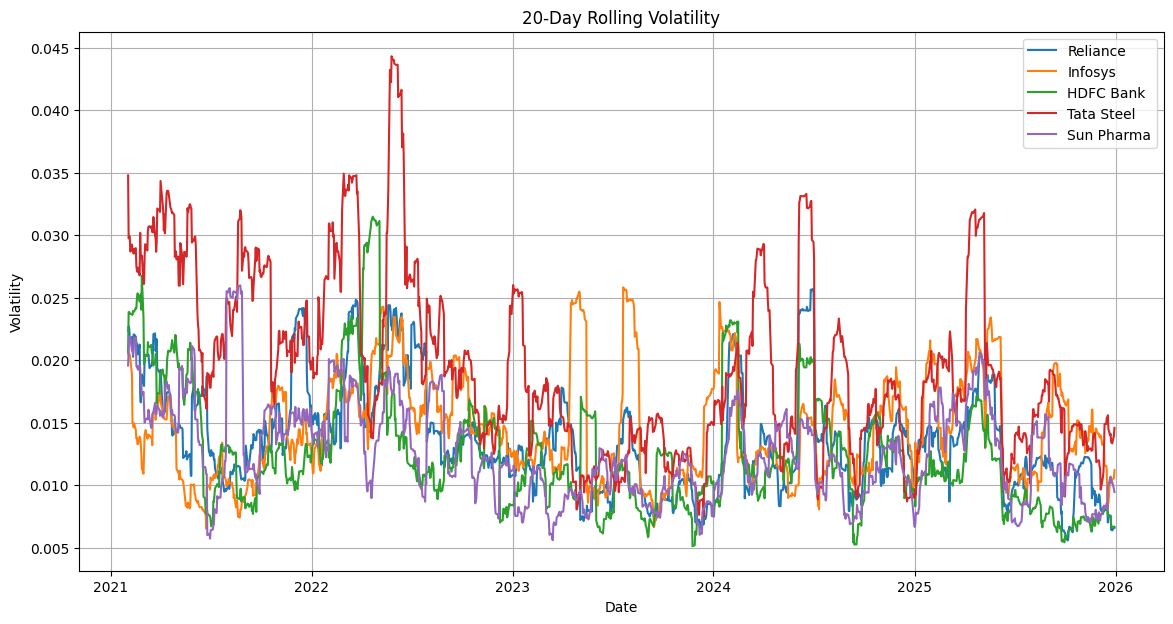

In [10]:
plt.figure(figsize=(14, 7))

for name, data in stock_data.items():

    returns = data['Close'].pct_change()
    volatility = returns.rolling(window=20).std()

    plt.plot(volatility, label=name)

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)

plt.show()

# Section 7 — ADF Stationarity Test

In [11]:
for name, data in stock_data.items():

    print(f"\nADF Test for {name}")

    result = adfuller(data['Close'].dropna())

    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

    if result[1] < 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-Stationary")


ADF Test for Reliance
ADF Statistic: -1.6857252124834246
p-value: 0.4384818773098051
Result: Non-Stationary

ADF Test for Infosys
ADF Statistic: -2.3999430070311076
p-value: 0.14175249517765098
Result: Non-Stationary

ADF Test for HDFC Bank
ADF Statistic: -1.3958721488929386
p-value: 0.5842534544886788
Result: Non-Stationary

ADF Test for Tata Steel
ADF Statistic: -1.753856137733938
p-value: 0.4035993057175894
Result: Non-Stationary

ADF Test for Sun Pharma
ADF Statistic: -0.8476235650005989
p-value: 0.8047313632632662
Result: Non-Stationary


# Section 8 — STL Decomposition


STL Decomposition for Reliance


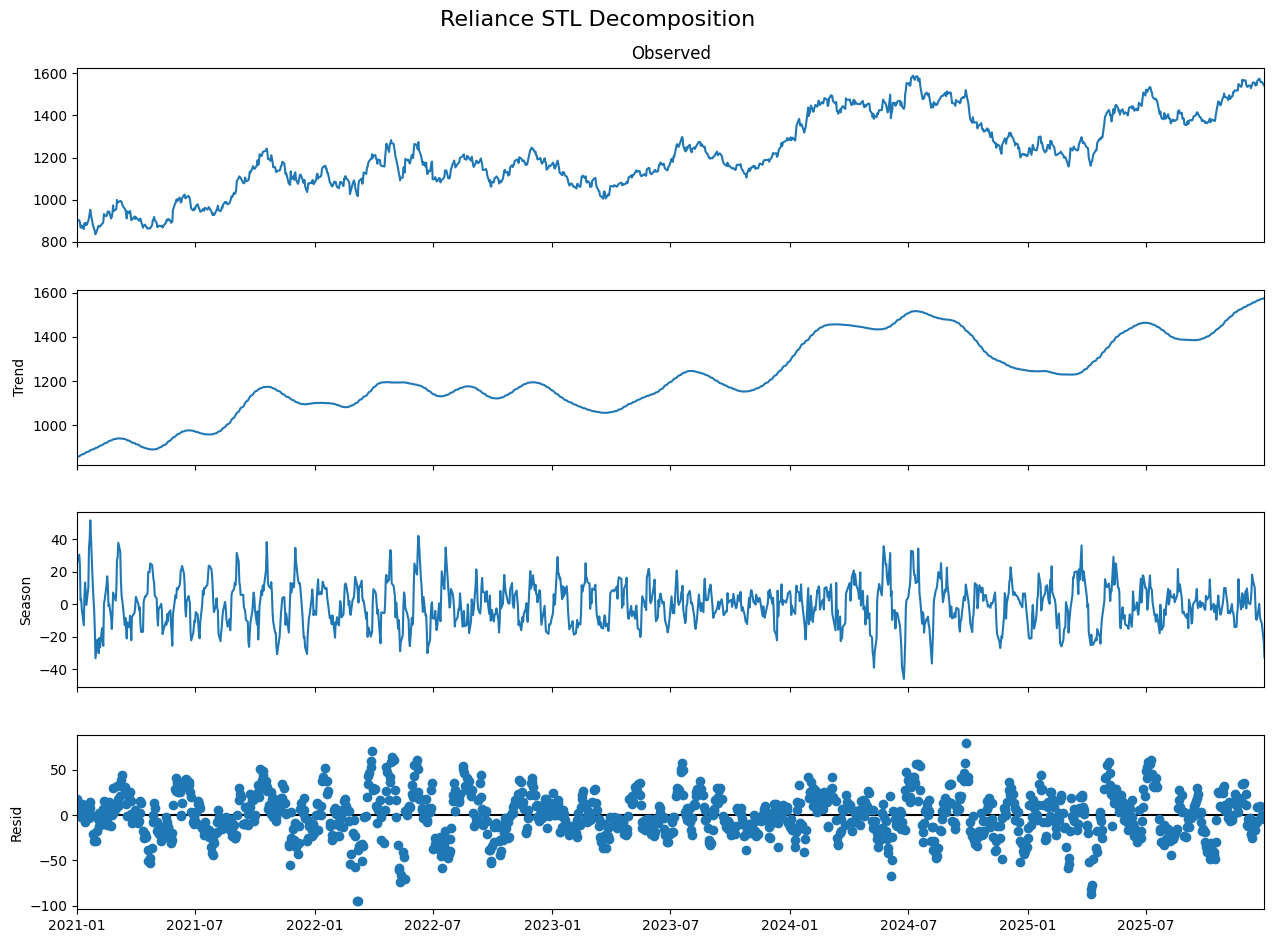


STL Decomposition for Infosys


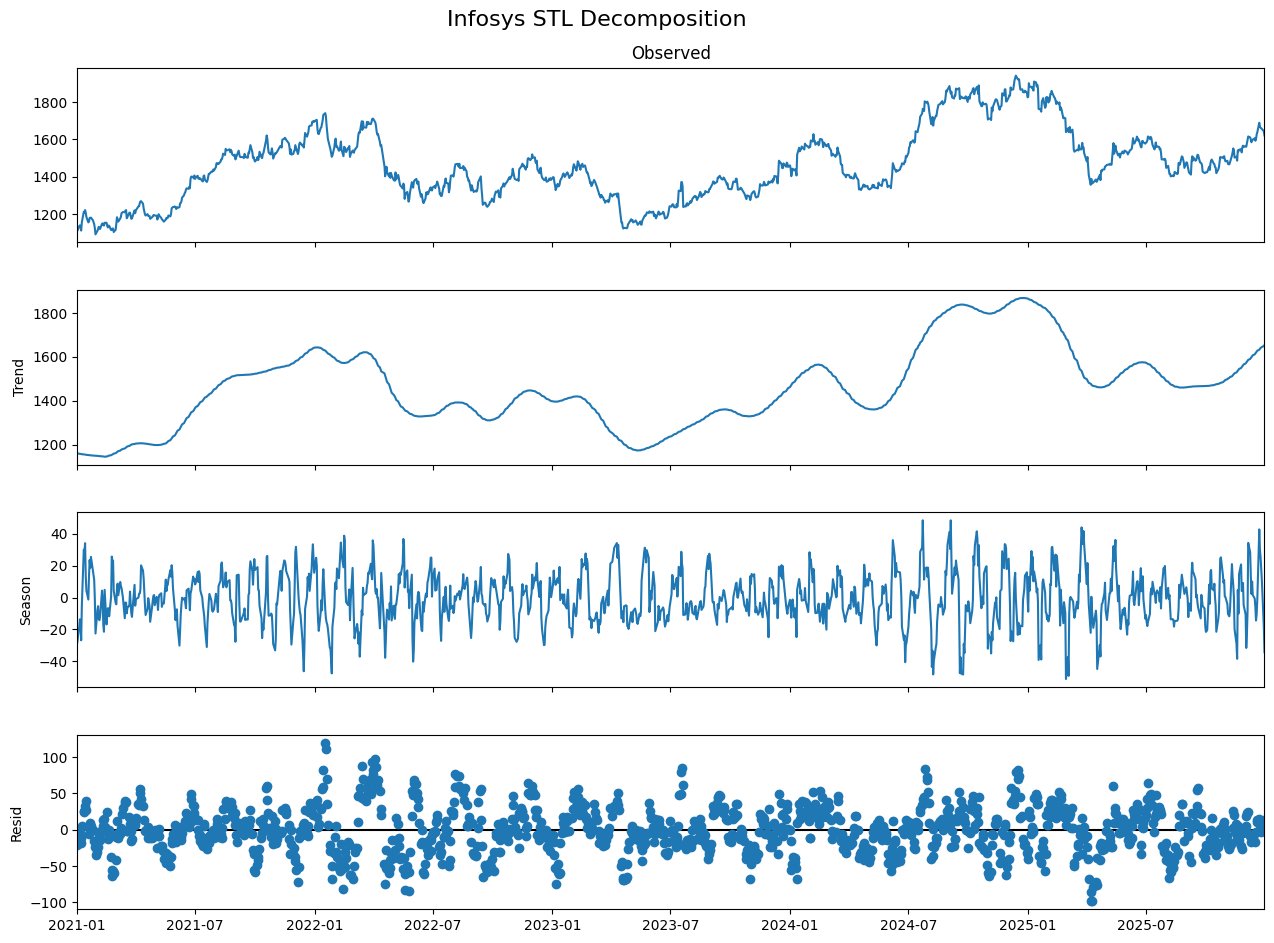


STL Decomposition for HDFC Bank


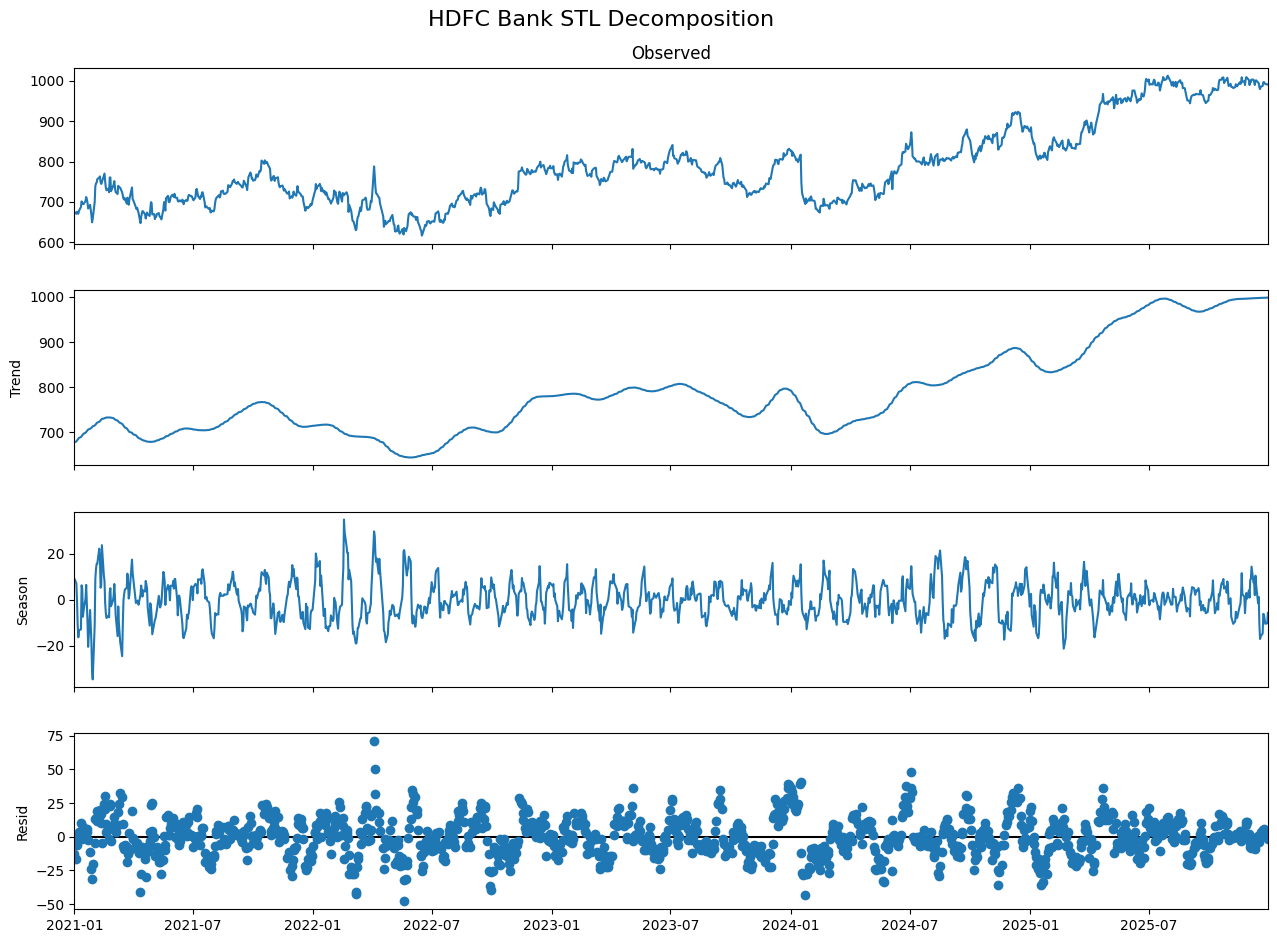


STL Decomposition for Tata Steel


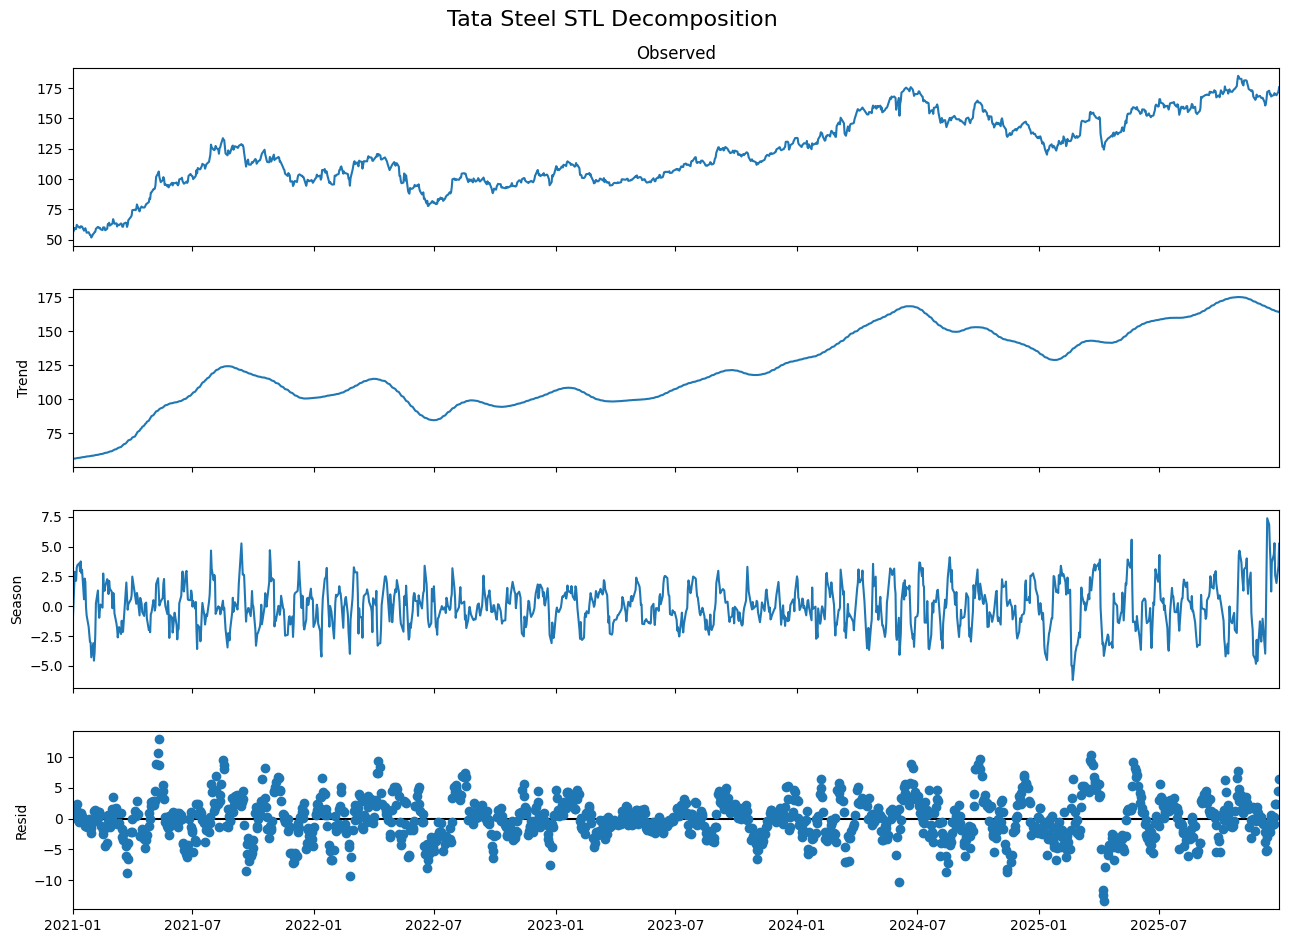


STL Decomposition for Sun Pharma


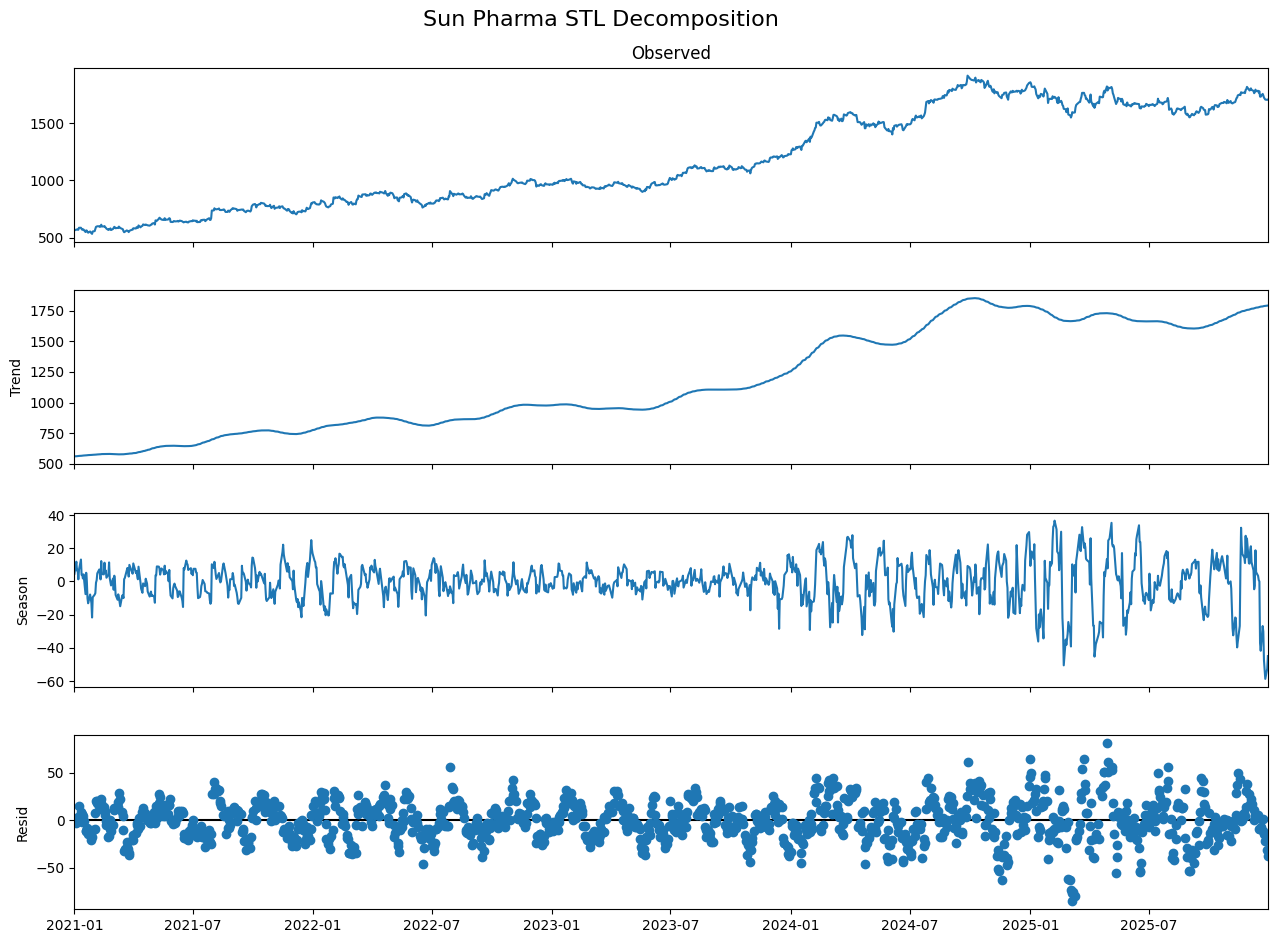

In [12]:
for name, data in stock_data.items():

    print(f"\nSTL Decomposition for {name}")

    close_price = data['Close']

    stl = STL(close_price, period=30)
    result = stl.fit()

    fig = result.plot()
    fig.set_size_inches(14, 10)

    plt.suptitle(f"{name} STL Decomposition", fontsize=16)

    plt.show()